# Install libraries and loading image
[Image](https://github.com/fxanhkhoa/AL-ML-Hackathon/blob/main/training/day-3-opencv/images/assigment_lane_line.png)

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,050 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,253 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Package

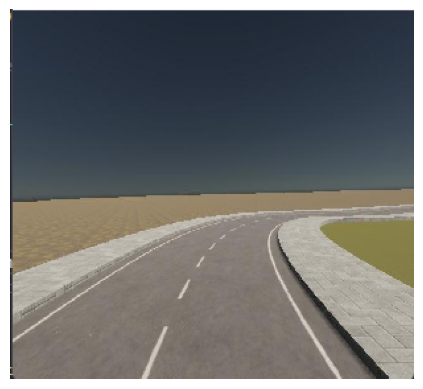

In [1]:
# prompt: load this image into cv2 of google colab https://github.com/fxanhkhoa/AL-ML-Hackathon/blob/main/training/day-3-opencv/images/assigment_lane_line.png

!apt-get update
!apt-get install -y libsm6 libxext6 libxrender-dev
!pip install opencv-python

import cv2
import matplotlib.pyplot as plt

# Download the image
!wget https://github.com/fxanhkhoa/AL-ML-Hackathon/raw/main/training/day-3-opencv/images/assigment_lane_line.png
# Load the image using OpenCV

image_path = 'assigment_lane_line.png'
image = cv2.imread(image_path)
# Display the image (optional)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Preprocessing the image
- blur
- grayscale
- thresholding

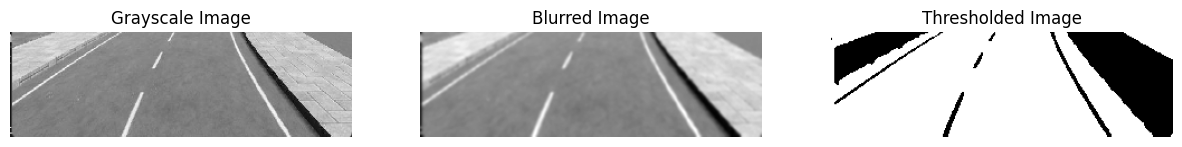

In [27]:
# prompt: # prompt:
# - blur
# # - grayscale
# # - thresholding
# # the image
# get 1/3 bottom of image

import matplotlib.pyplot as plt
# Calculate the height of the image
height, width = image.shape[:2]
# Crop to the bottom third
cropped_image = image[2 * height // 3:height, 0:width]
# Convert to grayscale
gray_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)
# Apply Gaussian blur
blur_gray = cv2.GaussianBlur(gray_image, (5, 5), 0)
# Apply thresholding (simple binary thresholding)
# Adjust the threshold value (e.g., 100) and max_value (e.g., 255) as needed
ret, thresh_image = cv2.threshold(blur_gray, 150, 255, cv2.THRESH_BINARY)
thresh_image = cv2.bitwise_not(thresh_image)
# Display the preprocessed images (optional)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(blur_gray, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(thresh_image, cmap='gray')
plt.title('Thresholded Image')
plt.axis('off')
plt.show()

# Finding the lane line
- Contouring
- Find the lane line
- Draw the center of laneline

Found 4 contours.
Largest contour has area: 18366.5


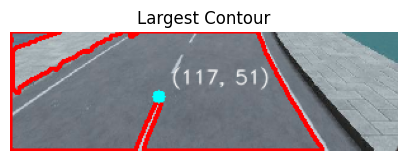

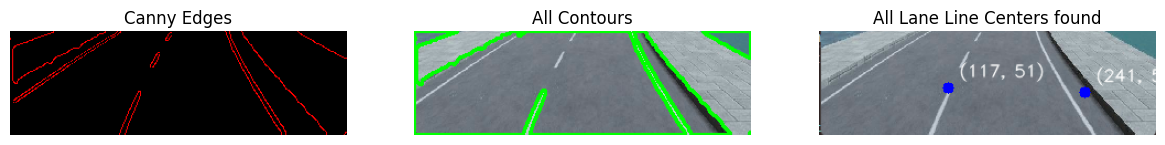

Lane line centers:
  (117, 51)
  (241, 55)


In [33]:
# prompt: # Finding the lane line
# - Contouring
# - Canny and Draw the Canny
# - Find the lane line
# - Log and draw all contour
# - Draw the center of laneline
# for thresh_image

import matplotlib.pyplot as plt
import numpy as np
# Finding contours
contours, hierarchy = cv2.findContours(thresh_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find the two largest contours (assuming these are the lane lines)
# Sort contours by area in descending order
contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Take the top two contours if they exist
lane_line_contours = contours[:2]

# Create a copy of the original cropped image to draw on
contour_image = cropped_image.copy()

# Canny edge detection on the thresholded image
canny_image = cv2.Canny(thresh_image, 50, 150)

# Draw the Canny edges
canny_output_image = np.zeros_like(cropped_image)
canny_output_image[..., 0] = canny_image # Draw Canny on one channel for display

# Log and draw all contours
print(f"Found {len(contours)} contours.")
# Draw all contours for visualization (optional)
all_contours_image = cropped_image.copy()
cv2.drawContours(all_contours_image, contours, -1, (0, 255, 0), 2) # Draw all contours in green

# Draw the center of the lane lines
center_image = cropped_image.copy()

lane_line_centers = []

if len(lane_line_contours) > 0:
    for contour in lane_line_contours:
        # Calculate the moments of the contour
        M = cv2.moments(contour)
        # Ensure M['m00'] is not zero to avoid division by zero
        if M['m00'] != 0:
            # Calculate the centroid (center of mass)
            cX = int(M['m10'] / M['m00'])
            cY = int(M['m01'] / M['m00'])

            lane_line_centers.append((cX, cY))

            # Draw a circle at the center
            cv2.circle(center_image, (cX, cY), 5, (0, 0, 255), -1) # Draw center in red
            # Define the text to display
            center_text = f"({cX}, {cY})"

            # Draw the text next to the center
            # The last argument is the text color (BGR: Blue, Green, Red)
            # The font scale and thickness can be adjusted for better visibility
            cv2.putText(center_image, center_text, (cX + 10, cY - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

# The lane line is the max contour
lane_line_contours = sorted(contours, key=cv2.contourArea, reverse=True)
max_contour = contours[0]
print(f"Largest contour has area: {cv2.contourArea(max_contour)}")

# You can then draw just this largest contour if needed
max_contour_image = cropped_image.copy()
cv2.drawContours(max_contour_image, [max_contour], -1, (255, 0, 0), 2) # Draw in blue

M = cv2.moments(max_contour)
# Ensure M['m00'] is not zero to avoid division by zero
if M['m00'] != 0:
    # Calculate the centroid (center of mass)
    cX = int(M['m10'] / M['m00'])
    cY = int(M['m01'] / M['m00'])

    # Draw a circle at the center
    cv2.circle(max_contour_image, (cX, cY), 5, (0, 255, 255), -1) # Draw center
    # Define the text to display
    center_text = f"({cX}, {cY})"

    # Draw the text next to the center
    # The last argument is the text color (BGR: Blue, Green, Red)
    # The font scale and thickness can be adjusted for better visibility
    cv2.putText(max_contour_image, center_text, (cX + 10, cY - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(5, 5))
plt.imshow(max_contour_image)
plt.title('Largest Contour')
plt.axis('off')
plt.show()

# Display the results
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(canny_output_image)
plt.title('Canny Edges')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(all_contours_image)
plt.title('All Contours')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(center_image)
plt.title('All Lane Line Centers found')
plt.axis('off')

plt.show()

if lane_line_centers:
    print("Lane line centers:")
    for center in lane_line_centers:
        print(f"  ({center[0]}, {center[1]})")
else:
    print("No lane line centers found.")